In [1]:
import jax
jax.default_device(jax.devices("cpu")[0])

In [2]:
import dill

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="ticks")
sns.set_theme()

In [3]:
base_path = "/home/bryanpu1/projects/aaai_2026/scaling_jax/results"
# algo_name = "cartpole_ad"
# run_name = "u_0_10-07-04-25_14_58_14-1da784d1-c8cd-47b4-bdc8-7250297071fd"

algo_name = "cartpole_stitch"
run_name = "u_0_10-07-04-25_14_58_17-14d90e14-50e0-44fe-8835-2873a2239d52"

algo_name = "cartpole_dpt"
run_name = "u_0_10-07-04-25_14_58_21-4585929c-51d2-4c4b-a2f4-5405bb283c13"

# algo_name = "cartpole_expi"
# run_name = "u_0_10-07-04-25_15_01_04-2cefecff-98c0-488d-a6b8-e2fd983a4562"

In [4]:
data = dill.load(open(f"{base_path}/{algo_name}/{run_name}/eval_info.dill", "rb"))

In [5]:
data.keys()

dict_keys(['episode_lengths', 'episode_returns', 'action_counts', 'logits', 'eval_config', 'env_params'])

/tmp/ipykernel_2362861/3571273813.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(


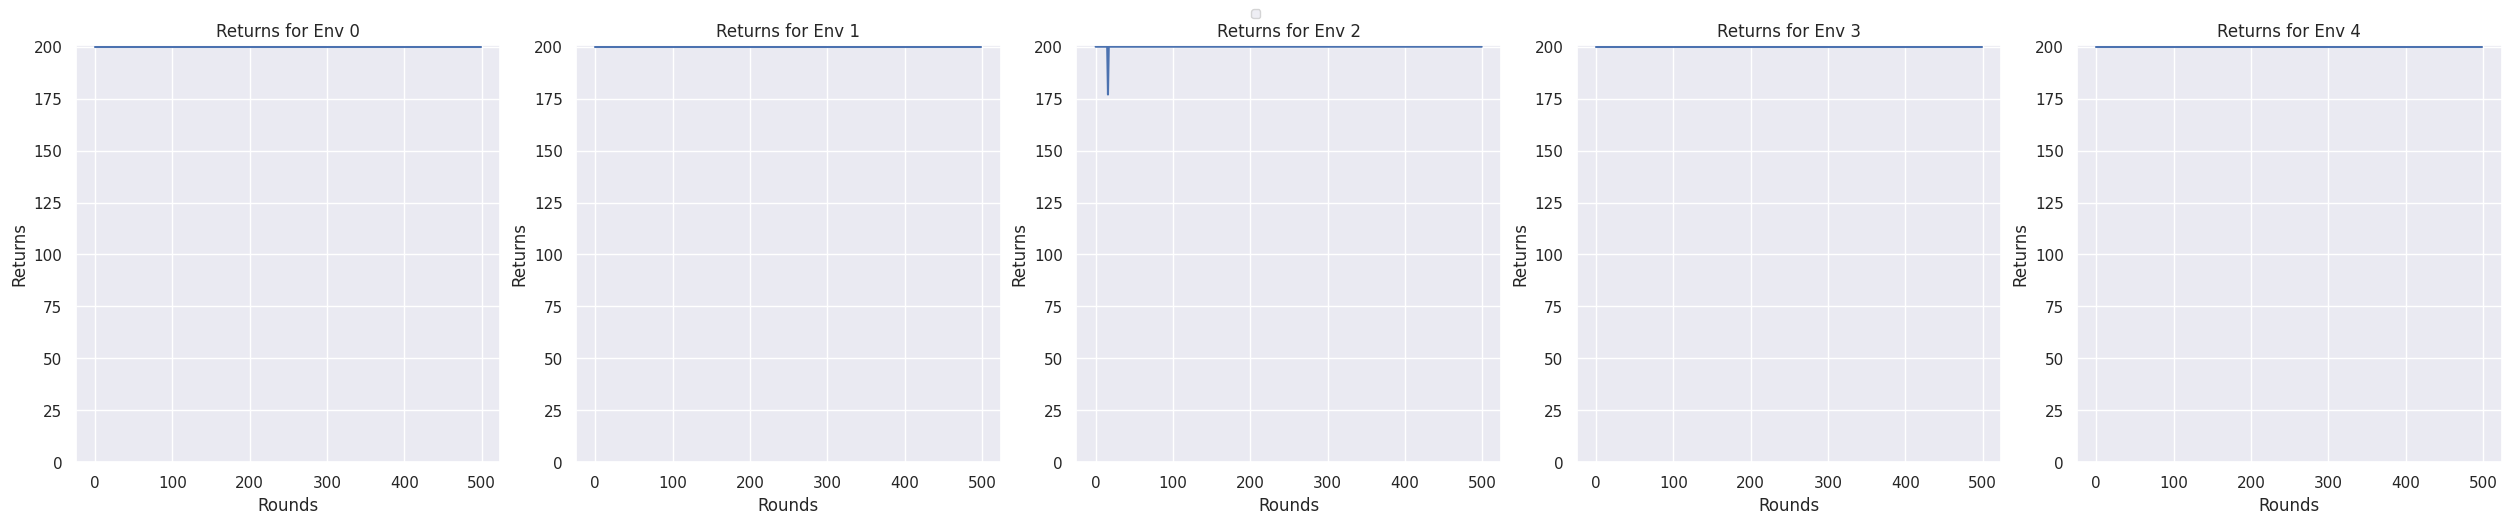

In [6]:

(num_envs, num_eps) = data["episode_lengths"].shape
xrange = range(num_eps)

num_cols = 5
num_rows = int(np.ceil(num_envs / 5))

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(5 * num_cols, 5 * num_rows),
    layout="constrained",
)

try:
    axes = axes.flatten()
except:
    axes = [axes]

for env_i in range(num_envs):
    axes[env_i].set_title(f"Returns for Env {env_i}")
    axes[env_i].set_xlabel("Rounds")
    axes[env_i].set_ylabel("Returns")

    xrange = np.arange(len(data["episode_returns"][env_i]))
    axes[env_i].plot(xrange, data["episode_returns"][env_i])
    # axes[env_i].plot(xrange, np.cumsum(data["episode_returns"][env_i]) / (xrange + 1))
    axes[env_i].set_ylim(0.0, 201.0)

fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=5,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8", 
)
fig.show()

In [7]:
print(data["action_counts"])

[[49991. 50009.]
 [49993. 50007.]
 [49992. 49985.]
 [49983. 50017.]
 [49991. 50009.]]


In [8]:
print(np.argmax(data["env_params"], axis=-1))

0


In [9]:
data["env_params"].item().gravity

Array([14.896704 , 13.374969 , 14.3843565, 10.838147 , 13.565767 ],      dtype=float32)